# Facial Recognition Model
This section covers the entire workflow for creating the facial recognition model. We will load the features extracted from the images, train a classifier to identify individuals, and thoroughly evaluate its performance.

## Step 1: Library Imports

In [5]:
# --- Implementation: Library Imports ---
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, log_loss, classification_report, 
                           confusion_matrix, roc_curve, auc)

## Step 2: Load and Prepare the Data
Goal: Load the `image_features.csv` dataset. We will then separate it into features (`X`) and labels (`y`), encode the text-based labels into numbers, scale the features for optimal model performance, and finally split the data into training and testing sets.

In [ ]:
def load_and_prepare_data(features_path):
    """Loads, preprocesses, and splits the image feature data."""
    print("--- Loading and Preparing Data ---")
    df = pd.read_csv(features_path)
    
    X = df.drop(columns=['person', 'augmentation_type'])
    y = df['person']

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("✅ Data prepared successfully.")
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, label_encoder

def train_model(X_train, y_train):
    """Initializes and trains a RandomForestClassifier."""
    print("\n--- Training RandomForest Model ---")
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    print("✅ Model training complete.")
    return model


def evaluate_model(model, X_test, y_test, X_columns, encoder):
    """
    Evaluates the model, prints performance metrics, and plots
    feature importance, confusion matrix, and ROC curves.
    """
    print("\n--- Evaluating Model Performance ---")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    # --- Print Metrics ---
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print(f"Log Loss: {loss:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=encoder.classes_))

    # --- Plot 1: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Person')
    plt.ylabel('Actual Person')
    plt.show()

    # --- Plot 2: Feature Importance ---
    importances = pd.Series(model.feature_importances_, index=X_columns)
    top_20 = importances.sort_values(ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_20.values, y=top_20.index)
    plt.title('Top 20 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.show()

    # --- Plot 3: ROC Curve for each class ---
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(encoder.classes_):
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, i], pos_label=i)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve for {class_name} (area = {roc_auc:.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.show()


def save_artifacts(model, scaler, encoder, output_dir):
    """Saves the model, scaler, and encoder to disk."""
    print("\n--- Saving Model Artifacts ---")
    os.makedirs(output_dir, exist_ok=True)
    joblib.dump(model, os.path.join(output_dir, 'face_recognition_model.pkl'))
    joblib.dump(scaler, os.path.join(output_dir, 'face_recognition_scaler.pkl'))
    joblib.dump(label_encoder, os.path.join(output_dir, 'face_recognition_encoder.pkl'))
    print(f"✅ Artifacts saved to '{output_dir}'")

## Step 3: Main Execution Workflow
Execute our entire workflow by calling the helper functions in the correct sequence.



--- Loading and Preparing Data ---
✅ Data prepared successfully.

--- Training RandomForest Model ---
✅ Model training complete.

--- Evaluating Model Performance ---
Accuracy: 0.9556
F1-Score (Weighted): 0.9539
Log Loss: 0.1387

Classification Report:
              precision    recall  f1-score   support

      Armand       1.00      0.78      0.88         9
     Benitha       1.00      1.00      1.00         9
   Christian       1.00      1.00      1.00         9
     Clinton       0.90      1.00      0.95         9
    Jeremiah       0.90      1.00      0.95         9

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.95        45
weighted avg       0.96      0.96      0.95        45



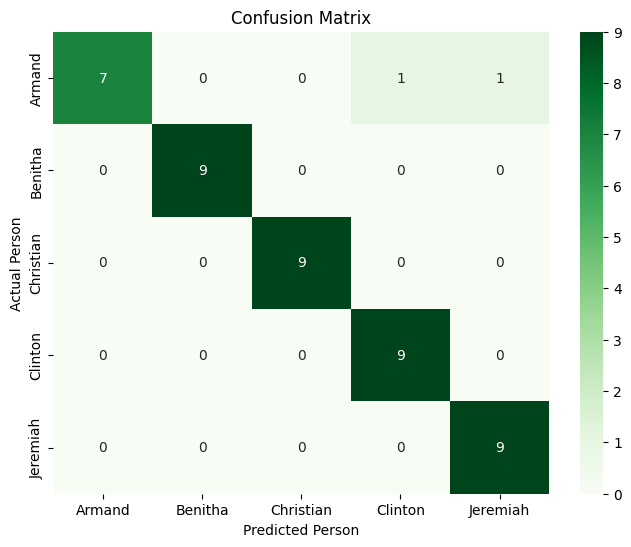

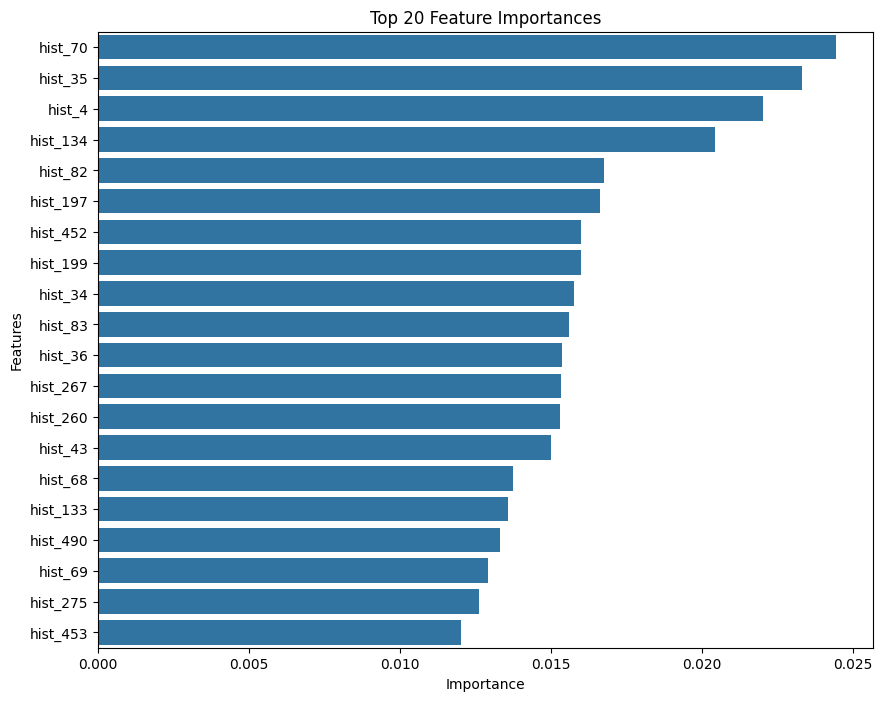

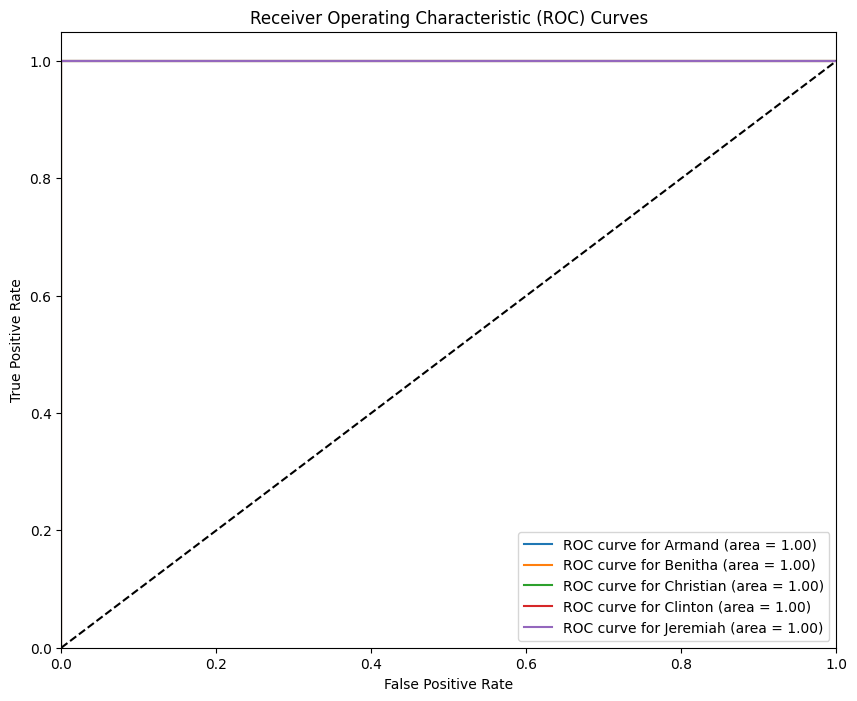


--- Saving Model Artifacts ---
✅ Artifacts saved to '../models/image/'

🎉 Facial Recognition training completed successfully!


In [8]:
# 1. Define file paths
features_path = '../data/outputs/image_features.csv'
model_output_dir = '../models/image/'

# 2. Load and prepare data
X_train, X_test, y_train, y_test, scaler, label_encoder = load_and_prepare_data(features_path)

# 3. Train the model
# We need the column names before they are scaled for plotting
X_columns = pd.read_csv(features_path).drop(columns=['person', 'augmentation_type']).columns
face_model = train_model(X_train, y_train)

# 4. Evaluate the model (with new plots)
evaluate_model(face_model, X_test, y_test, X_columns, label_encoder)

# 5. Save the final artifacts
save_artifacts(face_model, scaler, label_encoder, model_output_dir)

print("\n🎉 Facial Recognition training completed successfully!")

## Interpretation:
* **Overall Performance**: The model is highly effective. With an **accuracy of 95.6%** and a **weighted F1-Score of 0.95**, it demonstrates a strong and reliable ability to distinguish between the team members based on their images. The low **Log Loss of 0.1387** indicates that the model is also very confident in its correct predictions.

* **Confusion Matrix Analysis**: The confusion matrix visually confirms the high accuracy, with large numbers down the main diagonal. The model's primary area of weakness is in identifying "Armand," whom it sometimes misclassifies as "Clinton" or "Jeremiah". This directly explains the lower recall score (0.78) for Armand in the classification report.

* **Feature Importance**: The feature importance plot shows that the model uses a wide variety of histogram features to make its decisions. There is no single feature that dominates; rather, the model relies on a complex combination of color distribution data to identify individuals.

* **ROC Curves**: The ROC curves are exceptional. An Area Under the Curve (AUC) of **1.00 for every class** indicates perfect class separability based on the model's probability scores. This is an outstanding result and shows the model can distinguish each person from the others with a very high degree of confidence.